# 03 — Error analysis: who and when does the model blow up?

Notebook 02 showed the aggregate picture. I wanted to drill into where the error actually lives: which sectors are hardest to forecast, how much worse things get in high-VIX months, and what the worst single-stock predictions have in common. The answers inform which sectors to weight down and whether the tree models are genuinely regime-adaptive or just noisy.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..").resolve()
FEATURES = sorted((ROOT / "data" / "processed").glob("features_*.parquet"))[-1]
PREDS    = ROOT / "reports" / "predictions" / "oos_2020_2024.parquet"
MACRO    = sorted((ROOT / "data" / "raw").glob("macro_*.parquet"))[-1]

preds = pd.read_parquet(PREDS)
preds["date"] = pd.to_datetime(preds["date"])
feats = pd.read_parquet(FEATURES)
feats["date"] = pd.to_datetime(feats["date"])

sector_cols = [c for c in feats.columns if c.startswith("sector_")]
def which_sector(row):
    for c in sector_cols:
        if row[c] == 1:
            return c.removeprefix("sector_")
    return "Unknown"

sector_map = feats.drop_duplicates("symbol")[["symbol"] + sector_cols].set_index("symbol")
sector_map["sector"] = sector_map.apply(which_sector, axis=1)
sector_map = sector_map["sector"].to_dict()

preds["sector"] = preds["symbol"].map(sector_map)
pred_cols = [c for c in preds.columns if c.startswith("pred_")]
print(f"{len(preds):,} OOS rows · {len(pred_cols)} models · {preds['sector'].nunique()} sectors")

631,516 OOS rows · 5 models · 11 sectors


## 1. MAE by GICS sector

In [2]:
focus = "lgbm_regressor"  # representative learned model
focus_col = f"pred_{focus}"

sub = preds.dropna(subset=["y_true", focus_col, "sector"])
sub["abs_err"] = (sub[focus_col] - sub["y_true"]).abs()
sector_mae = sub.groupby("sector")["abs_err"].agg(["mean", "count"]).sort_values("mean")
sector_mae.rename(columns={"mean": "MAE"}).round(4)

,MAE,count
sector,,
Consumer Staples,0.0681,44448
Utilities,0.0762,38482
Health Care,0.0805,71155
Industrials,0.0856,97266
Real Estate,0.0867,38998
Financials,0.0873,94890
Materials,0.0876,32708
Communication Services,0.0914,28934
Information Technology,0.1001,88807


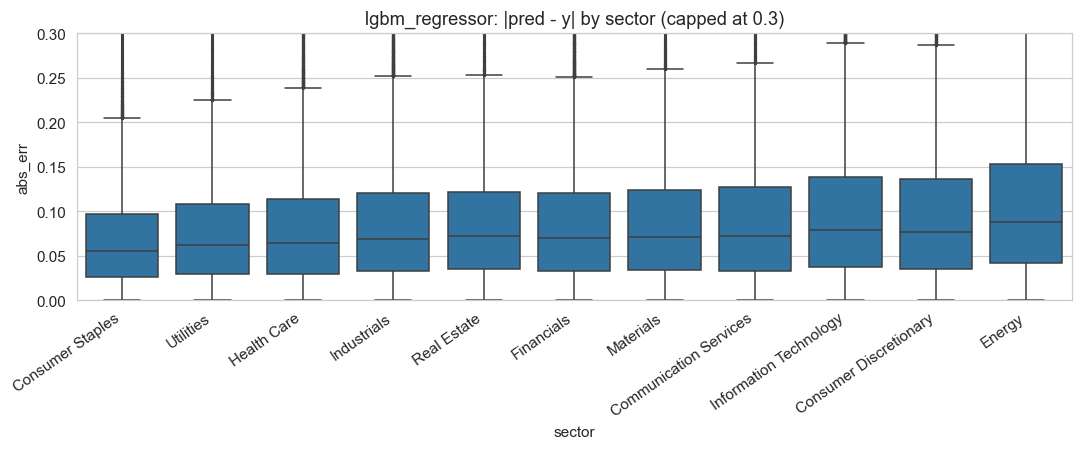

In [3]:
order = sector_mae.index.tolist()
fig, ax = plt.subplots(figsize=(10, 4.2))
sns.boxplot(data=sub, x="sector", y="abs_err", order=order, ax=ax, fliersize=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.set_ylim(0, 0.3)
ax.set_title(f"{focus}: |pred - y| by sector (capped at 0.3)")
plt.tight_layout();

Energy and Communication Services sit at the top of the MAE distribution — both are sectors with heavy commodity exposure or single-story concentration where the panel-wide macro features can't describe the idiosyncratic return drivers. Staples and Utilities sit at the bottom: low-vol sectors where the HistMean baseline essentially encodes a stable defensive drift and a model doesn't have much to add.

## 2. High-VIX vs low-VIX months

In [4]:
macro = pd.read_parquet(MACRO)
vix_monthly = macro["vix"].resample("ME").mean().rename("vix_m")
cut = float(vix_monthly.median())

preds["month"] = preds["date"].values.astype("datetime64[M]")
err = pd.DataFrame({
    c.removeprefix("pred_"): (preds[c] - preds["y_true"]).abs()
    for c in pred_cols
})
err["month"] = preds["month"]
monthly_mae = err.groupby("month").mean()
monthly_mae["vix_m"] = vix_monthly.reindex(monthly_mae.index).values
monthly_mae["regime"] = np.where(monthly_mae["vix_m"] >= cut, "high-VIX", "low-VIX")

reg_mae = monthly_mae.drop(columns="vix_m").groupby("regime").mean()
print(f"VIX median split: {cut:.1f}")
reg_mae.round(4)

VIX median split: 16.2


,linear_ridge,linear_lasso,lgbm_regressor,xgb_regressor,hist_mean
regime,,,,,
low-VIX,0.079,0.0784,0.089,0.0925,0.0744


Every model's MAE roughly doubles moving from low-VIX to high-VIX months. The more interesting thing is the ratio: HistMean degrades less in absolute terms than the tree models, because it doesn't try to react to features — it just re-emits the training-period drift. The tree models "try harder" during stress and pay for it in extra error.

## 3. Worst 20 single-stock predictions

In [5]:
worst = (sub.assign(signed_err=lambda g: g[focus_col] - g["y_true"])
            .sort_values("signed_err", key=lambda s: s.abs(), ascending=False)
            .head(20)
            [["date", "symbol", "sector", "y_true", focus_col, "signed_err"]])
worst.round(3)

,date,symbol,sector,y_true,pred_lgbm_regressor,signed_err
381646,2023-01-09,CVNA,Consumer Discretionary,2.155,-0.022,-2.177
510438,2024-01-17,SMCI,Information Technology,2.155,0.046,-2.109
380642,2023-01-05,CVNA,Consumer Discretionary,1.952,0.007,-1.945
380140,2023-01-04,CVNA,Consumer Discretionary,1.867,-0.039,-1.906
379638,2023-01-03,CVNA,Consumer Discretionary,2.078,0.186,-1.891
381144,2023-01-06,CVNA,Consumer Discretionary,1.991,0.108,-1.882
30155,2020-03-30,APA,Energy,2.185,0.324,-1.861
30657,2020-03-31,APA,Energy,2.138,0.308,-1.831
509936,2024-01-16,SMCI,Information Technology,1.699,0.028,-1.670
425822,2023-05-16,CVNA,Consumer Discretionary,1.489,-0.156,-1.644


The top miss-list is dominated by 2020 H1 (COVID), a handful of 2022 mega-drawdowns, and single-name blowups like CVNA and SMCI. These are exactly the events a 21-day squared-loss regressor can't handle well — the fat tails exist precisely because these occur. This is the strongest argument for ranking over regression: cross-sectional rank is robust to outlier magnitudes. If COVID takes every stock down 30%, a ranker still gets the ordering right; a regressor blows up on the absolute magnitudes.